In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
data=pd.read_csv("data_cts_violent_and_sexual_crime (1).csv")
data.head(10)

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
0,AZE,Azerbaijan,Asia,Western Asia,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,155.0,CTS
1,BEL,Belgium,Europe,Western Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,61959.0,CTS
2,BGR,Bulgaria,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,3806.0,CTS
3,BHR,Bahrain,Asia,Western Asia,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,2701.0,CTS
4,BLR,Belarus,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,4032.0,CTS
5,BMU,Bermuda,Americas,Northern America,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,522.0,CTS
6,BRN,Brunei Darussalam,Asia,South-eastern Asia,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,470.0,CTS
7,CAN,Canada,Americas,Northern America,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,48135.0,CTS
8,CHE,Switzerland,Europe,Western Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,6732.0,CTS
9,CMR,Cameroon,Africa,Sub-Saharan Africa,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,2998.0,CTS/NSO


In [6]:
dataPulito=data[data["VALUE"]!=0]

In [7]:
data["Indicator"].unique()

array(['Violent offences', 'Victims of serious assault',
       'Victims of sexual violence'], dtype=object)

In [8]:
violenze=data[data["Indicator"]=='Violent offences'][["Region","Unit of measurement","VALUE"]].groupby(["Region","Unit of measurement"]).sum("VALUE")
violenze

VALUE
Region   Unit of measurement                      
Africa   Counts                       7.191780e+06
         Rate per 100,000 population  4.980145e+04
Americas Counts                       8.293793e+07
         Rate per 100,000 population  2.818899e+05
Asia     Counts                       1.630745e+07
         Rate per 100,000 population  5.339391e+04
Europe   Counts                       5.149472e+07
         Rate per 100,000 population  2.443704e+05
Oceania  Counts                       2.334724e+06
         Rate per 100,000 population  2.239873e+04

In [9]:
data["Unit of measurement"].unique()

array(['Counts', 'Rate per 100,000 population'], dtype=object)

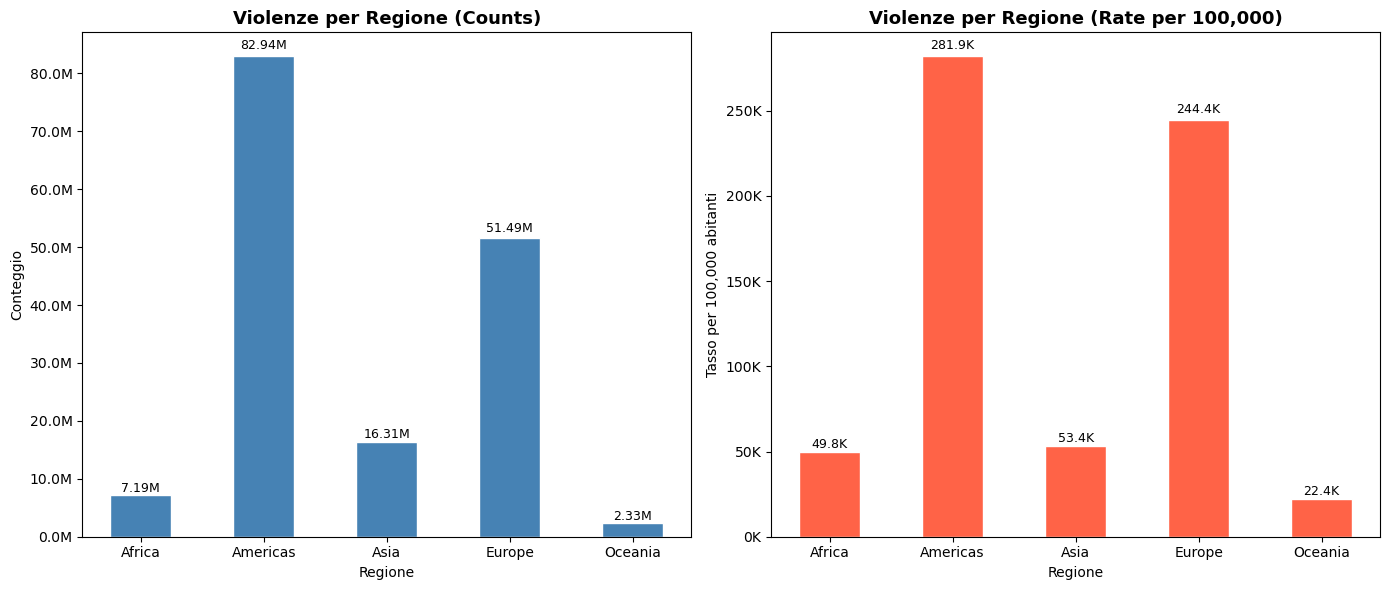

In [10]:
# Estrarre i dati dal DataFrame
counts = violenze.xs("Counts", level="Unit of measurement")["VALUE"]
rates = violenze.xs("Rate per 100,000 population", level="Unit of measurement")["VALUE"]

regioni = counts.index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Grafico 1: Counts ---
bars1 = ax1.bar(regioni, counts, color="steelblue", edgecolor="white", width=0.5)
ax1.set_title("Violenze per Regione (Counts)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Regione")
ax1.set_ylabel("Conteggio")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f"{bar.get_height()/1e6:.2f}M", ha="center", va="bottom", fontsize=9)

# --- Grafico 2: Rate per 100,000 ---
bars2 = ax2.bar(regioni, rates, color="tomato", edgecolor="white", width=0.5)
ax2.set_title("Violenze per Regione (Rate per 100,000)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Regione")
ax2.set_ylabel("Tasso per 100,000 abitanti")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f"{bar.get_height()/1e3:.1f}K", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("violenze_per_regione.png", dpi=150)
plt.show()

In [11]:
data[data["Region"]=="Asia"].groupby("Region").min() #è stato un anno tabù -> questo fa pensare non che non siano avvenute violenze ma che semplicemente non ci sono state denunce fatte

,Iso3_code,Country,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
Region,,,,,,,,,,,,
Asia,ARE,Armenia,Central Asia,Victims of serious assault,by relationship to perpetrator,Acts intended to induce fear or emotional dist...,Female,Total,2003,Counts,0.0,CTS


In [12]:
data[data["Region"]=="Asia"].groupby("Region").max()

,Iso3_code,Country,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
Region,,,,,,,,,,,,
Asia,YEM,Yemen,Western Asia,Violent offences,by type of offence,Sexual violence: Sexual assault,Total,Total,2024,"Rate per 100,000 population",334669.0,MoI/CTS


In [13]:
data[
    (data["Region"] == "Europe") &
    ((data["Country"] == "Ukraine") | (data["Country"] == "Russian Federation"))
].groupby("Year").sum("VALUE")

,VALUE
Year,
2003,45716.425896
2004,385016.974606
2005,488356.511146
2006,491384.843298
2007,411834.673185
2008,360531.394502
2009,308185.486874
2010,249719.501979
2011,184010.657744


In [14]:
def grafico(ax,continente):
    valori=dataPulito[dataPulito["Region"]==continente].groupby("Year").sum("VALUE")
    anni=dataPulito[dataPulito["Region"]==continente]["Year"].unique()
    ax.plot(anni,valori,marker='o')

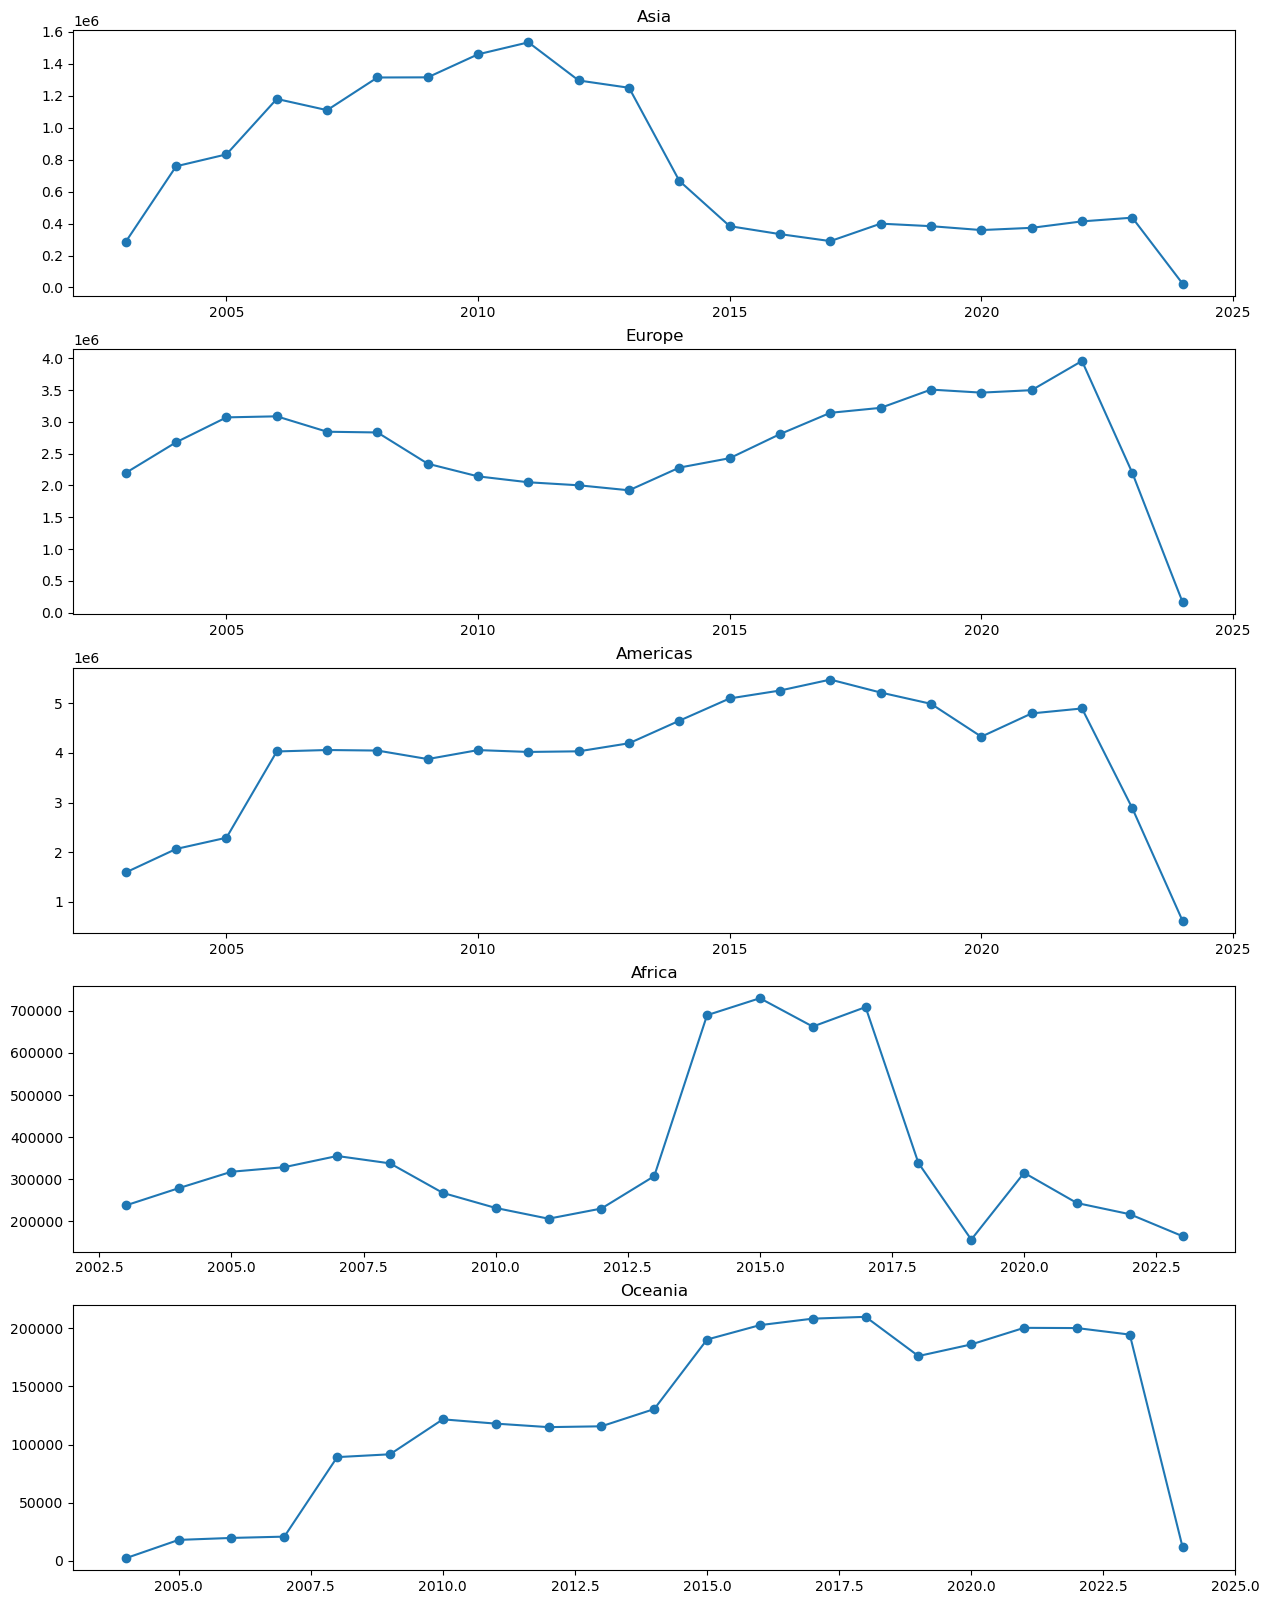

In [15]:
continenti=data["Region"].unique()
fig, axs= plt.subplots(nrows=5, figsize=(15,20))

for i,c in enumerate(continenti):
    grafico(axs[i],c)
    axs[i].set_title(c)

plt.show()

In [16]:
data["Sex"].unique()

array(['Total', 'Male', 'Female'], dtype=object)

In [17]:
data["Dimension"].unique()

array(['by type of offence', 'by relationship to perpetrator'],
      dtype=object)

In [28]:
data[data["Country"]=="Ukraine"]

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
50,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,5703.000000,CTS/DMDB
119,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2004,Counts,5538.000000,CTS/DMDB
207,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2005,Counts,6707.000000,CTS/DMDB
306,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2006,Counts,6464.000000,CTS/DMDB
400,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2007,Counts,5716.000000,CTS/DMDB
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30218,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Robbery,Total,Total,2007,"Rate per 100,000 population",68.559460,CTS
30318,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Robbery,Total,Total,2008,"Rate per 100,000 population",78.871530,CTS
30418,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Robbery,Total,Total,2009,"Rate per 100,000 population",59.193032,CTS
30521,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Robbery,Total,Total,2010,"Rate per 100,000 population",50.154983,CTS


## Cosa fare
- analizzare le diverse violenze [quindi le category] per 'by type of offence' ALESSIA
- analizzare le diverse violenze [quindi le category] per 'by relationship to perpetrator' REBECCA
- analizzare nei periodi di guerra continente o stati KIRTI

### Analizzare le diverse violenze [quindi le category] per 'by relationship to perpetrator' REBECCA

In [29]:
relationship = data[data['Dimension'] == "by relationship to perpetrator"]

In [134]:
relationshipPerRegione = relationship["Region"].value_counts()
relationshipPerRegione

Region
Europe      3496
Americas    2306
Asia         498
Oceania      164
Africa        64
Name: count, dtype: int64

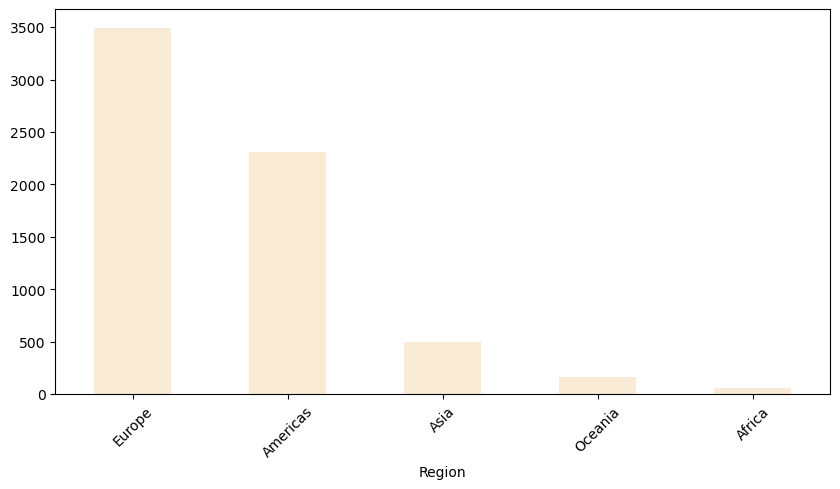

In [139]:
fig, ax = plt.subplots(figsize=(10,5))
relationshipPerRegione.plot(kind="bar", ax=ax, color="antiquewhite")
plt.xticks(rotation=45)
plt.show()

In [69]:
relationship["Category"].unique()

array(['Intimate partner or family member',
       'Other Perpetrator known to the victim',
       'Perpetrator unknown to the victim',
       'Relationship to perpetrator is not known'], dtype=object)

#### Fidanzato o membro della famiglia

In [70]:
intimi = relationship[relationship["Category"] == 'Intimate partner or family member']
#intimi
#1858 righe

In [120]:
intimiPerPaese = intimi["Country"].value_counts()
intimiPerPaese

Country
Austria                                       80
Germany                                       80
Slovenia                                      80
Slovakia                                      80
Finland                                       80
Canada                                        80
Switzerland                                   80
Colombia                                      76
Lithuania                                     64
Romania                                       64
Czechia                                       56
Latvia                                        56
France                                        56
Bolivia (Plurinational State of)              56
Spain                                         56
Croatia                                       48
Mexico                                        48
Saint Kitts and Nevis                         48
Guatemala                                     48
El Salvador                                   48
Myanmar     

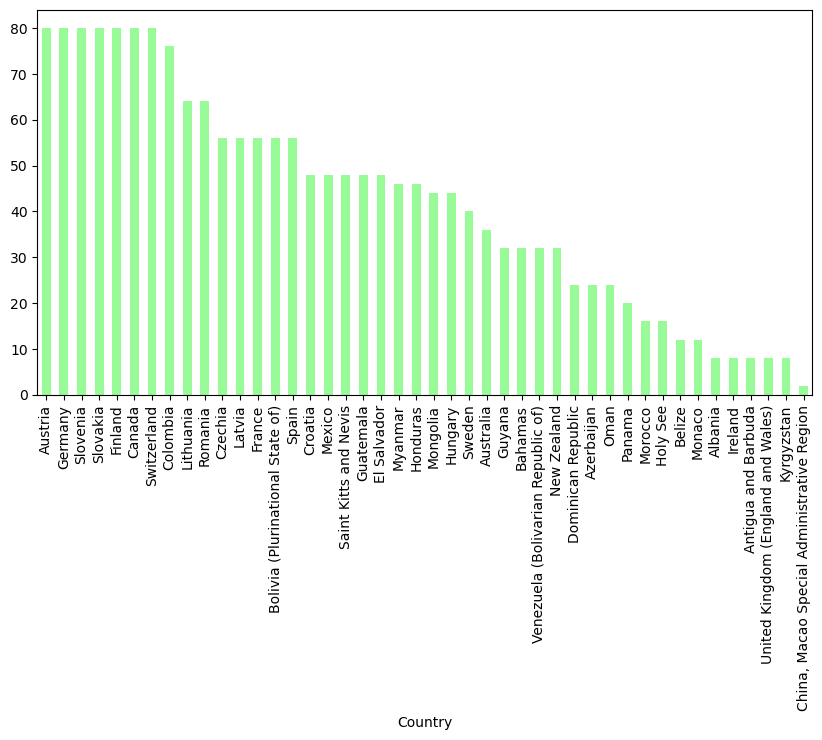

In [140]:
fig, ax = plt.subplots(figsize=(10,5))
intimiPerPaese.plot(kind="bar", ax=ax, color="palegreen")

plt.show()

### Conoscente

In [141]:
conoscenti = relationship[relationship["Category"] == 'Other Perpetrator known to the victim']
#conoscenti
#1460 righe

In [142]:
conoscentiPerPaese = conoscenti["Country"].value_counts()
conoscentiPerPaese

Country
Austria                               80
Switzerland                           80
Canada                                80
Colombia                              76
Germany                               72
Lithuania                             64
Bolivia (Plurinational State of)      56
Spain                                 56
Latvia                                56
Czechia                               56
Myanmar                               50
Mexico                                48
El Salvador                           48
Guyana                                48
Croatia                               48
Saint Kitts and Nevis                 48
Honduras                              46
Mongolia                              44
Sweden                                40
New Zealand                           32
Slovakia                              32
Venezuela (Bolivarian Republic of)    32
Bahamas                               32
Slovenia                              32
Hungary 

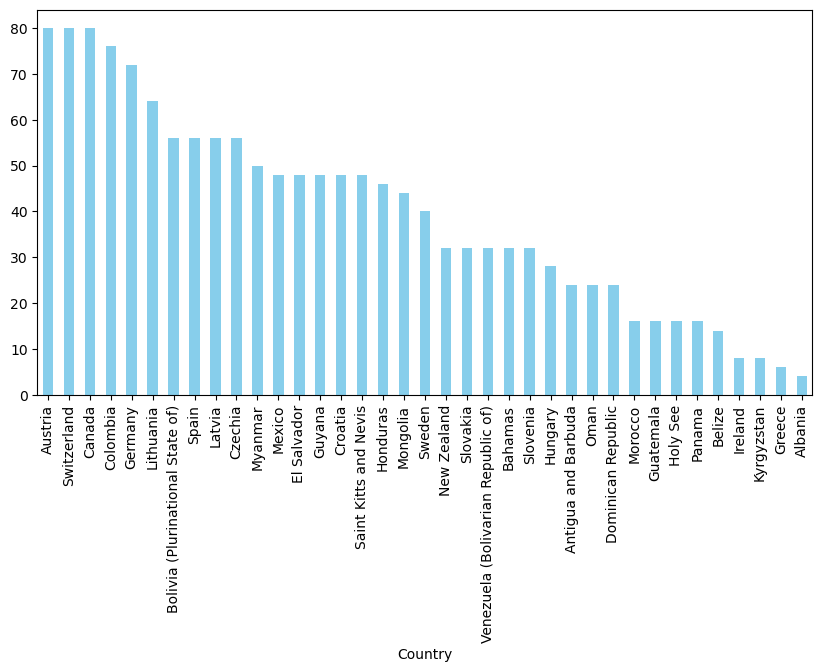

In [143]:
fig, ax = plt.subplots(figsize=(10,5))
conoscentiPerPaese.plot(kind="bar", ax=ax, color="skyblue")

plt.show()

### Sconosciuto

In [144]:
sconosciuti = relationship[relationship["Category"] == 'Perpetrator unknown to the victim']
#sconosciuti
#1478 righe

In [145]:
sconosciutiPerPaese = sconosciuti["Country"].value_counts()
sconosciutiPerPaese

Country
Austria                               80
Switzerland                           80
Canada                                80
Slovenia                              80
Colombia                              76
Germany                               72
Lithuania                             64
Slovakia                              64
Spain                                 56
Latvia                                56
Czechia                               56
Sweden                                56
Myanmar                               50
Mexico                                48
El Salvador                           48
Saint Kitts and Nevis                 48
Croatia                               48
Mongolia                              44
Bolivia (Plurinational State of)      40
New Zealand                           32
Honduras                              32
Venezuela (Bolivarian Republic of)    32
Bahamas                               32
Guyana                                32
Hungary 

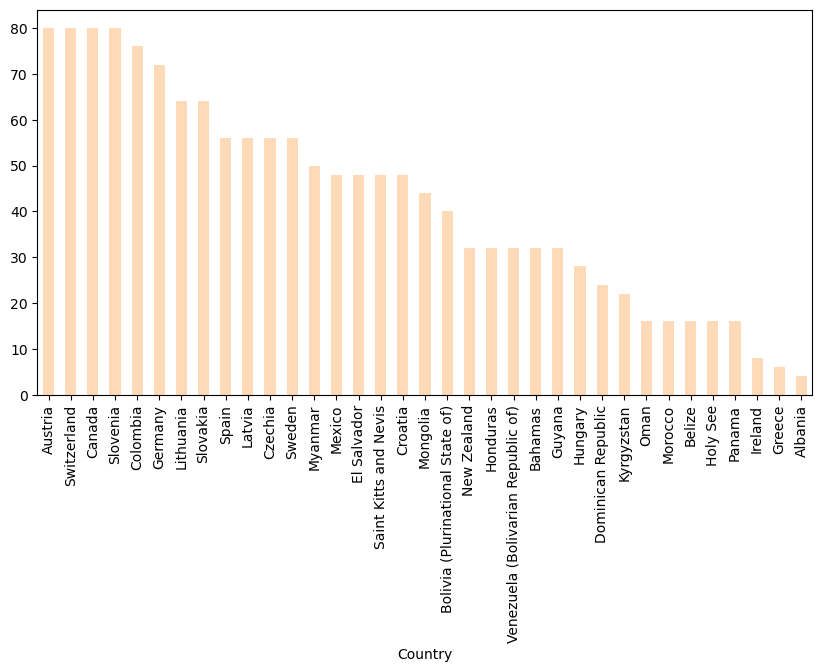

In [146]:
fig, ax = plt.subplots(figsize=(10,5))
sconosciutiPerPaese.plot(kind="bar", ax=ax, color="peachpuff")

plt.show()

### Ignoto

In [147]:
ignoti = relationship[relationship["Category"] == 'Relationship to perpetrator is not known']
#ignoti
#1732 righe

In [148]:
ignotiPerPaese = ignoti["Country"].value_counts()
ignotiPerPaese

Country
Austria                               80
Switzerland                           80
Finland                               80
Sweden                                80
Canada                                80
Colombia                              72
Germany                               72
Italy                                 64
Lithuania                             64
Norway                                64
Spain                                 56
Czechia                               56
Bolivia (Plurinational State of)      56
Poland                                56
France                                52
Saint Kitts and Nevis                 48
Croatia                               48
Mexico                                44
Guyana                                44
Latvia                                40
Honduras                              40
Azerbaijan                            40
Mongolia                              36
Guatemala                             36
Venezuel

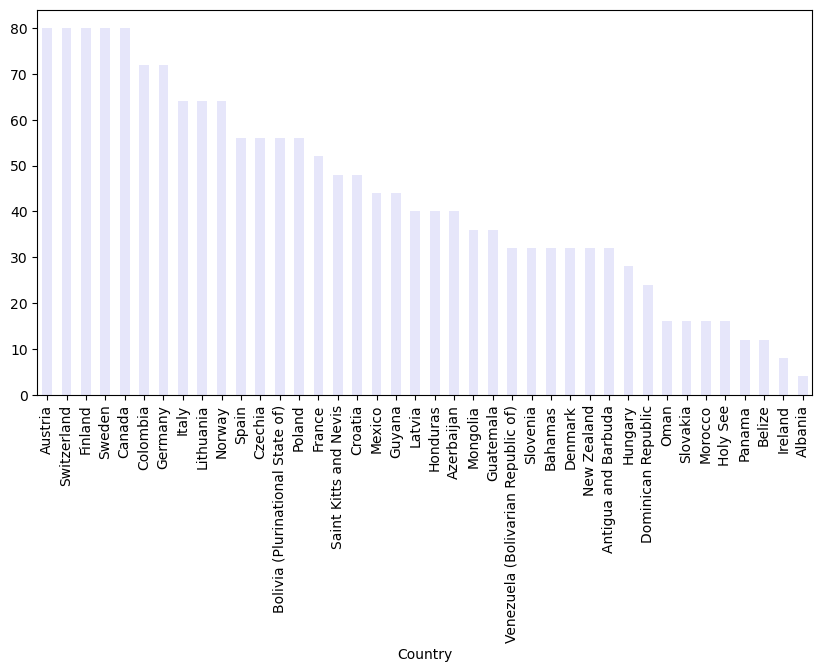

In [149]:
fig, ax = plt.subplots(figsize=(10,5))
ignotiPerPaese.plot(kind="bar", ax=ax, color="lavender")

plt.show()